# Edge-weighted Graph Decomposition

Decompose a synthetic edge-weighted graph with overlapping cliques using **Top-NMF** with a graph filtration persistence complex, and compare against standard NMF.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
from itertools import combinations

from TopNMF import (
    TopologicalNMF,
    GraphFiltrationPH,
    clique_deviation_loss,
    generate_edge_weighted_graph,
    plot_gallery_graph,
)
from TopNMF.visualization import FitMonitor

X shape: (3, 36), edges: 36


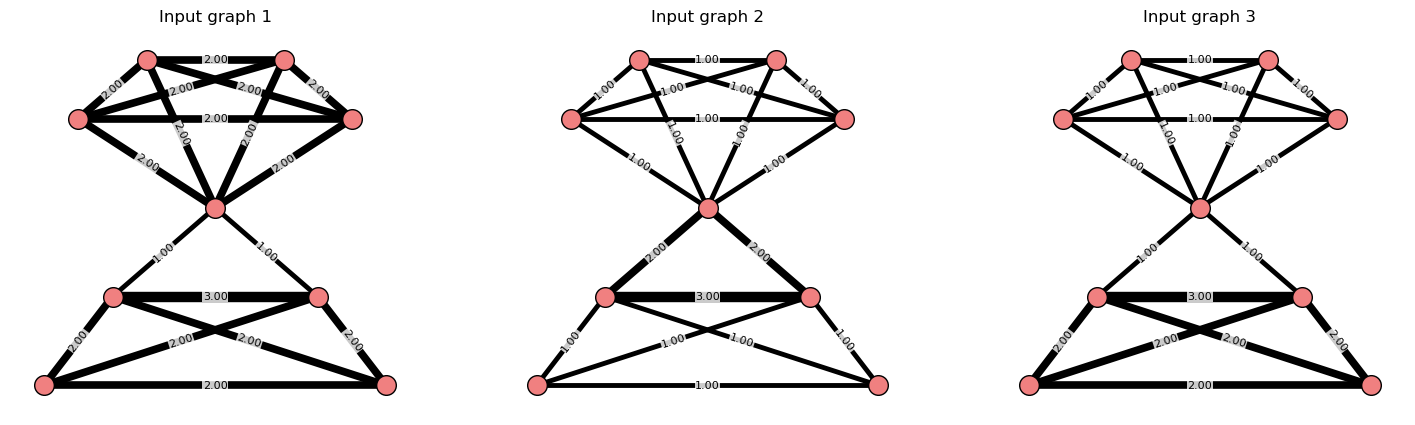

In [4]:
X, all_edges = generate_edge_weighted_graph()
print(f"X shape: {X.shape}, edges: {len(all_edges)}")
fixed_pos = {
    5: (0, 0),
    4: (-2, 1.5), 3: (-1, 2.5), 2: (1, 2.5), 1: (2, 1.5),
    6: (-1.5, -1.5), 7: (1.5, -1.5), 8: (-2.5, -3.0), 9: (2.5, -3.0),
}

_=plot_gallery_graph(X, torch.tensor(all_edges).T, title="Input graph", pos=fixed_pos)

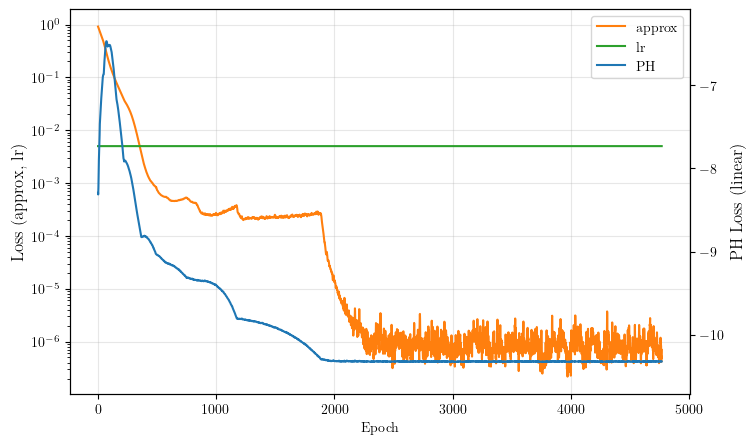

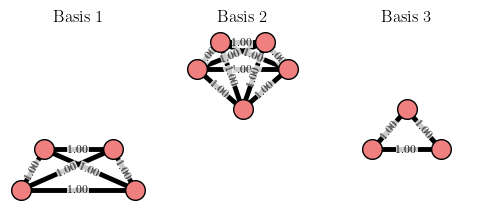

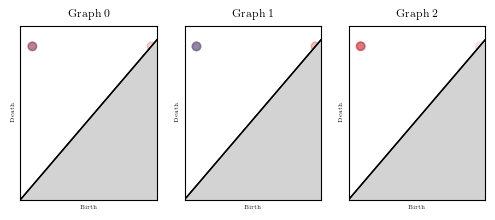

  0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
device = "cpu"
n_components = 3

# Superlevel graph filtration tracking H0 and H1
ph_complex = GraphFiltrationPH(max_dim=1, superlevel=True)

# Empty target diagrams encourage topologically simple bases
target_diagrams = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=43,
    complex=ph_complex,
    use_embedding=False,
    ph_loss_fn=clique_deviation_loss,
    ph_loss_params={"alpha": 1.0, "remove_longest": {0: False, 1: False}},
)

monitor = FitMonitor(
    show=["loss", "PH", "basis"],
    interval=10,
    grid=(1, 3),
    superlevel=True,
)

model.fit(
    X,
    n_iterations=5000,
    lr=0.005,
    lambda_top=0.01,
    PH_dims=[0, 1],
    complex_inputs={"all_edges": all_edges, "node_pos": fixed_pos},
    verbose=True,
    target_diagrams=target_diagrams,
    normalize_V_max=True,
    init_method="random",
    monitor=monitor,
)

plt.close("all")

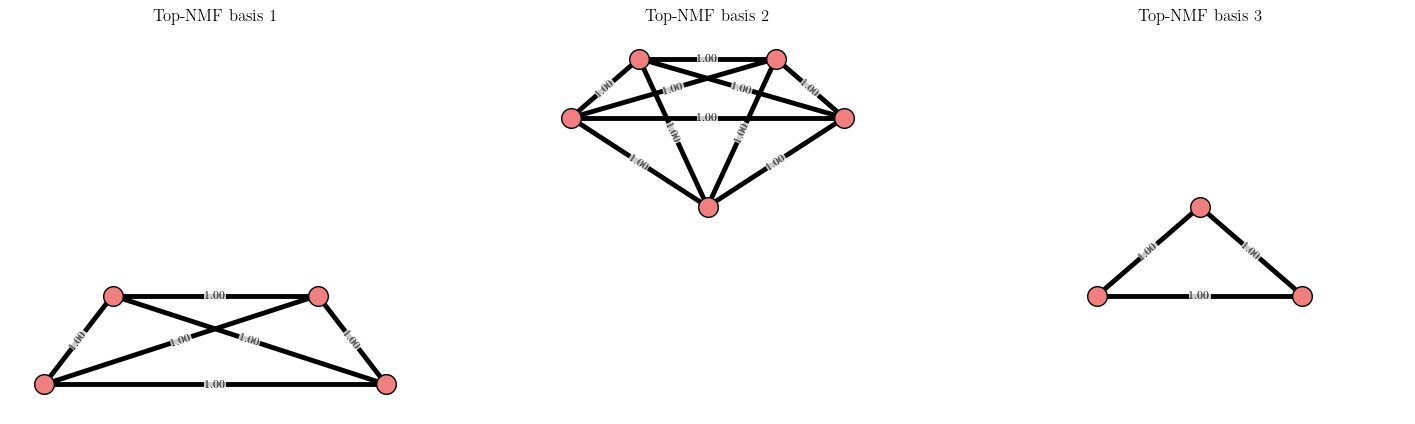

In [6]:
# Top-NMF basis vectors
_=plot_gallery_graph(
    model.V.detach().cpu().numpy(),
    torch.tensor(all_edges).T,
    title="Top-NMF basis",
    pos=fixed_pos,
)

## Compare with standard NMF

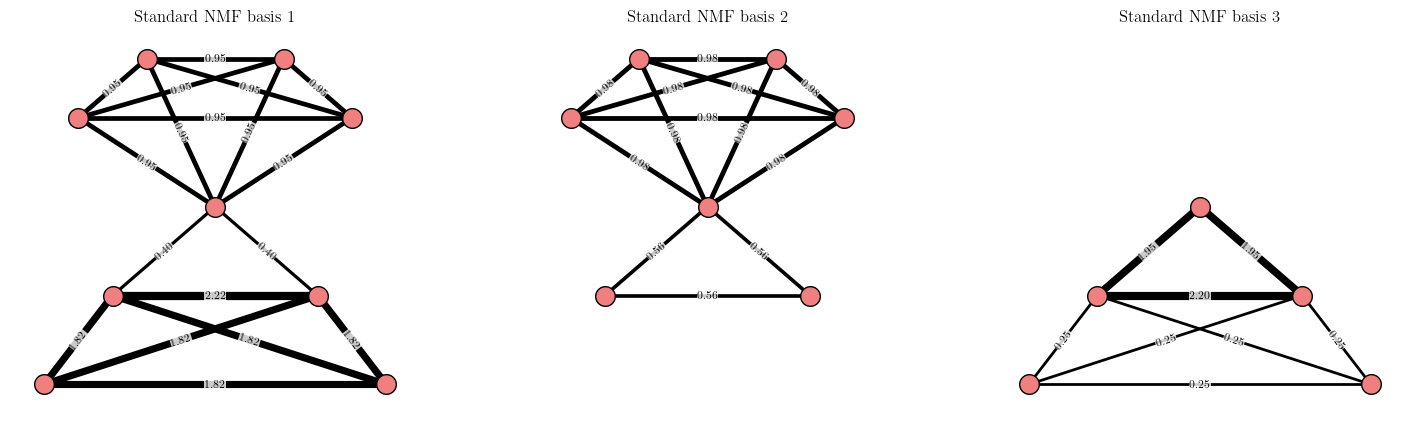

In [7]:
from sklearn.decomposition import NMF

# Standard NMF on the same edge-weight matrix
nmf = NMF(n_components=n_components, init="random", random_state=43)
W_std = nmf.fit_transform(X)
H_std = nmf.components_

# Standard NMF basis vectors
_=plot_gallery_graph(
    H_std,
    torch.tensor(all_edges).T,
    title="Standard NMF basis",
    pos=fixed_pos,
)